### Aim : To implement a **Logistic Regression** model to classify credit card transactions as **fraudulent or legitimate**.


NAME: Diksha Ajay Sapale
ROLL NO: cs48

## Objectives

1. To understand the mathematical foundations of **Logistic Regression** and the **Sigmoid Function**.
2. To understand and handle **class imbalance** in credit card fraud datasets.
3. To implement **Gradient Descent** for optimizing Logistic Regression parameters.
4. To evaluate the model using **Confusion Matrix, Precision, Recall, F1-Score, ROC Curve, and AUC**.
5. To understand the importance of **Recall and False Negative Rate** in fraud detection.


## Relevant Theory

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for **binary classification**. In this experiment, it is used to classify credit card transactions into two classes:

- **0 $\rightarrow$ Legitimate transaction**
- **1 $\rightarrow$ Fraudulent transaction**

The model first calculates a linear combination of input features:

$$
z = w^T X + b
$$

where:

- $w$ = weight vector
- $X$ = input feature vector
- $b$ = bias/intercept
- $z$ = linear predictor

---

### Sigmoid Function

The Sigmoid Function converts the value of $z$ into a probability between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability that a transaction is fraudulent is:

$$
P(y=1|X) = \sigma(w^T X + b)
$$

The predicted class can be obtained using a threshold:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y=1|X) \geq 0.5 \\
0, & \text{if } P(y=1|X) < 0.5
\end{cases}
$$

---
## Cost Function

Logistic Regression uses the **Binary Cross-Entropy Loss** or **Log Loss**.

The cost function is:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

- $m$ = number of training examples
- $y_i$ = actual class label
- $\hat{y}_i$ = predicted probability

The objective of training is to find values of $w$ and $b$ that minimize the cost function.

---

## Gradient Descent

Gradient Descent is used to optimize the parameters of the Logistic Regression model.

The weights are updated using:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

The bias is updated using:

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

For Logistic Regression, the gradient of the cost function with respect to the weights can be expressed as:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

The gradient with respect to the bias is:

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
$$

Therefore, the parameter updates become:

$$
w := w - \alpha
\left[
\frac{1}{m}X^T(\hat{y}-y)
\right]
$$

$$
b := b - \alpha
\left[
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
\right]
$$

---

## Class Imbalance

Credit card fraud datasets are generally highly imbalanced because legitimate transactions significantly outnumber fraudulent transactions.

For example, the dataset may contain a very large number of legitimate transactions and only a small number of fraudulent transactions.

A model that predicts most transactions as legitimate may achieve high accuracy but perform poorly at detecting fraud.

Therefore, techniques such as:

- Random Undersampling
- Oversampling
- Class Weighting

can be used to handle class imbalance.

---

## Evaluation Metrics

### Confusion Matrix

The confusion matrix consists of four components:

- **True Positive (TP):** Fraudulent transaction correctly identified as fraud.
- **True Negative (TN):** Legitimate transaction correctly identified as legitimate.
- **False Positive (FP):** Legitimate transaction incorrectly identified as fraud.
- **False Negative (FN):** Fraudulent transaction incorrectly identified as legitimate.

---

### Accuracy

Accuracy measures the proportion of correctly classified transactions:

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

However, accuracy alone is not sufficient for highly imbalanced fraud detection datasets.

---

### Precision

Precision indicates the proportion of transactions predicted as fraudulent that are actually fraudulent:

$$
Precision =
\frac{TP}
{TP+FP}
$$

A high Precision means that the model produces fewer false fraud alerts.

---

### Recall

Recall measures the proportion of actual fraudulent transactions correctly detected:

$$
Recall =
\frac{TP}
{TP+FN}
$$

Recall is particularly important in fraud detection because a **False Negative** represents a fraudulent transaction that was not detected.

---

### F1-Score

F1-Score is the harmonic mean of Precision and Recall:

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

---

## ROC Curve

The Receiver Operating Characteristic (ROC) curve represents the relationship between the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** at different classification thresholds.

The True Positive Rate is:

$$
TPR =
\frac{TP}
{TP+FN}
$$

The False Positive Rate is:

$$
FPR =
\frac{FP}
{FP+TN}
$$

The ROC curve helps determine how well the model separates fraudulent transactions from legitimate transactions.

---

## *Area Under the Curve (AUC)*

The **Area Under the ROC Curve (AUC)** summarizes the performance of the classifier across different classification thresholds.

An AUC value close to:

$$
AUC = 1
$$

indicates excellent discrimination, while:

$$
AUC = 0.5
$$

indicates performance approximately equivalent to random classification.

---

### Dataset Information

The Credit Card Fraud Dataset contains transaction-related features such as transaction amount, distance from home, purchase-price-related ratios, and transaction characteristics.

The target variable is fraud:


0 → Legitimate transaction

1 → Fraudulent transaction

---

## Task 1: Environment Setup and Dataset Acquisition

Use dataset for this experiment [Credit Card Fraud Dataset](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)

Import the required Python libraries such as **NumPy, Pandas, Matplotlib, and Scikit-learn**.

Load the **Credit Card Fraud Dataset** into a Pandas DataFrame.

Display the following information:

* First five records of the dataset.
* Shape of the dataset.
* Column names.
* Data types of all columns.
* Descriptive statistics of numerical features.

Identify the **feature variables** and the **target variable** `fraud`.

The target variable is defined as:

$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

fraud =

* 0 -> Legitimate transaction

* 1 -> Fraudulent transaction


The objective of this task is to understand the structure of the dataset and identify the input features and target variable required for building the Logistic Regression model.

Identify the feature variables and the target variable fraud.

In [2]:

# Import required libraries
import os
import pandas as pd
import numpy as np

# Load dataset
dataset_path = "cardekho_dataset.csv"

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
else:
    print("ERROR: card_transdata.csv file not found.")
    print("Please upload the correct CSV file.")

# Display dataset columns
if 'df' in globals():
    print("\n--- DATASET COLUMNS ---")
    print(df.columns.tolist())

    print("\n--- FIRST 5 ROWS ---")
    print(df.head())

Dataset loaded successfully!

--- DATASET COLUMNS ---
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

--- FIRST 5 ROWS ---
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00 

## Task 2: Perform Exploratory Data Analysis

Perform **Exploratory Data Analysis (EDA)** to understand the structure, distribution, and characteristics of the Credit Card Fraud Dataset.

Calculate and display the following:

* Number of **legitimate transactions**.
* Number of **fraudulent transactions**.
* Percentage of legitimate transactions.
* Percentage of fraudulent transactions.
* Distribution of numerical features.

The percentage of each class can be calculated using:
$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

Plot the **class distribution** using a suitable visualization such as a bar chart.

Analyze the class distribution and explain the problem of **classification imbalance** in credit card fraud detection.

A dataset is considered highly imbalanced when the number of legitimate transactions is significantly greater than the number of fraudulent transactions. Therefore, accuracy alone may not be sufficient to evaluate the performance of the fraud detection model.


--- CLASS DISTRIBUTION ---
Legitimate Transactions (0) : 912,597 (91.2597%)
Fraudulent Transactions (1) : 87,403 (8.7403%)
Total Transactions          : 1,000,000


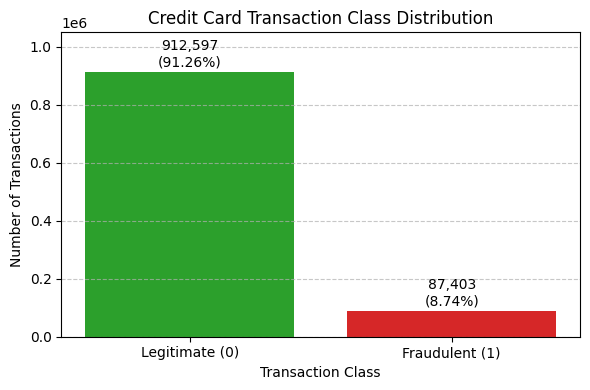

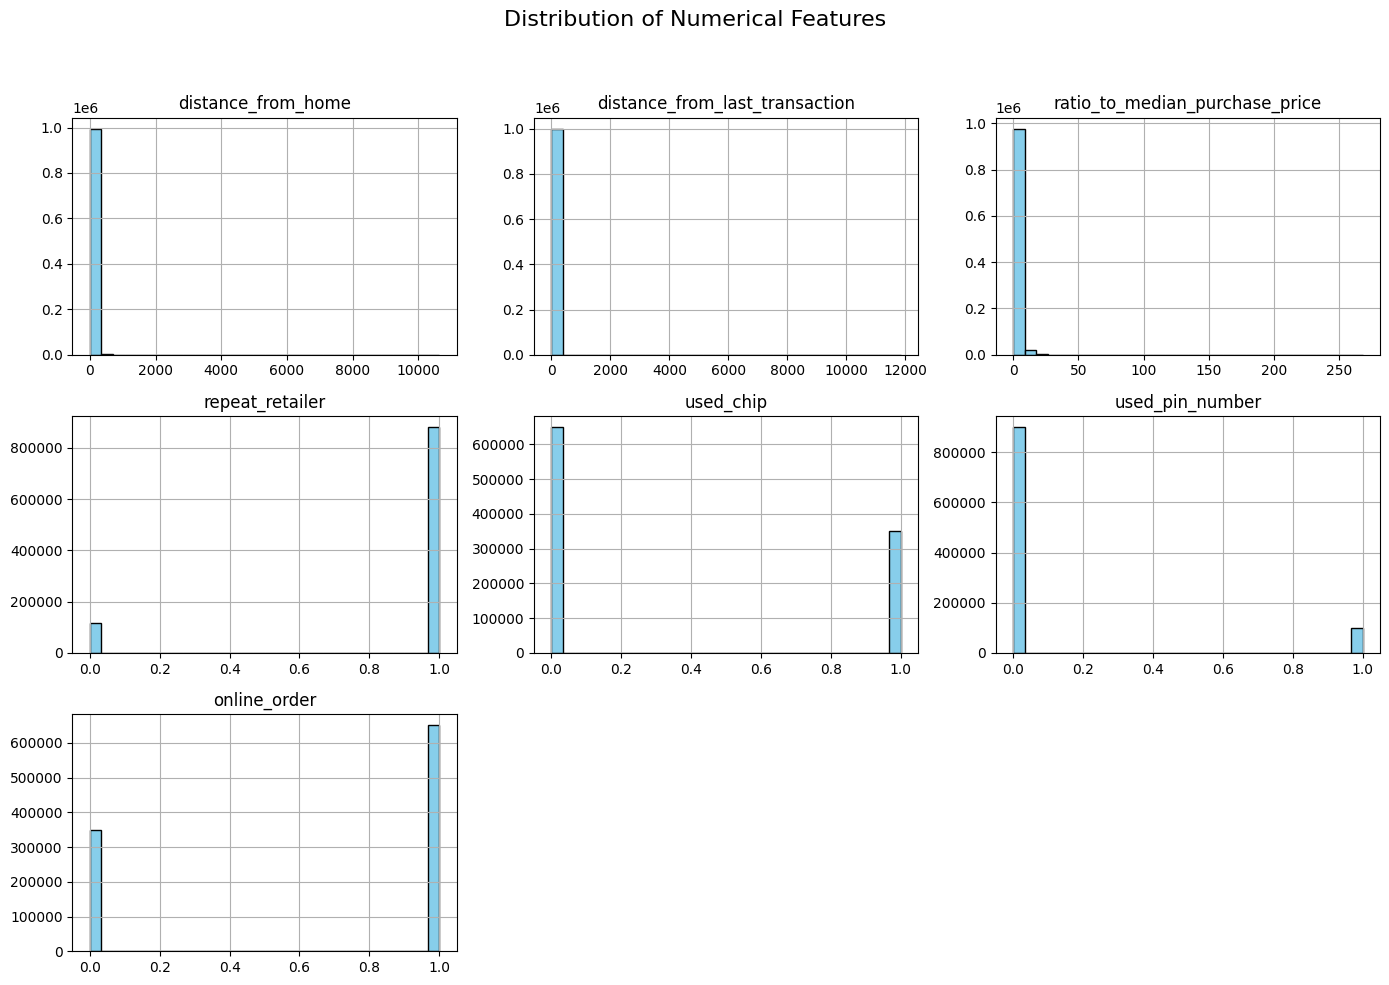


ANALYSIS: THE PROBLEM OF CLASS IMBALANCE IN FRAUD DETECTION
1. High Skewness: Legitimate transactions represent ~91.26% of the dataset, 
   while fraudulent transactions represent only ~8.74%.
   
2. Inadequacy of Accuracy Metric: 
   A naive model that predicts every transaction as "Legitimate" (0) will achieve 
   an Accuracy of 91.26%. However, its Recall for fraud detection will be 0%, 
   failing to catch a single fraudulent transaction.

3. Need for Specialized Metrics: 
   Instead of accuracy, models must be evaluated using metrics like Precision, 
   Recall, F1-Score, and ROC-AUC—focusing heavily on minimizing False Negatives 
   (missed fraud).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (assuming Task 1 loaded df)
# df = pd.read_csv("card_transdata.csv")

total_transactions = len(df)
legit_count = (df['fraud'] == 0).sum()
fraud_count = (df['fraud'] == 1).sum()

legit_pct = (legit_count / total_transactions) * 100
fraud_pct = (fraud_count / total_transactions) * 100

# 1. Display transaction counts and percentages
print("--- CLASS DISTRIBUTION ---")
print(f"Legitimate Transactions (0) : {legit_count:,} ({legit_pct:.4f}%)")
print(f"Fraudulent Transactions (1) : {fraud_count:,} ({fraud_pct:.4f}%)")
print(f"Total Transactions          : {total_transactions:,}")

# 2. Plot Class Distribution Bar Chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Legitimate (0)', 'Fraudulent (1)'], [legit_count, fraud_count], color=['#2ca02c', '#d62728'])
plt.title('Credit Card Transaction Class Distribution')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')

# Annotate count and percentage on top of bars
for bar, pct in zip(bars, [legit_pct, fraud_pct]):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10000, f'{yval:,}\n({pct:.2f}%)', ha='center', va='bottom')

plt.ylim(0, total_transactions * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Distribution of Numerical Features
df.drop(columns=['fraud']).hist(figsize=(14, 10), bins=30, edgecolor='black', color='skyblue')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 4. Analysis and Explanation of Classification Imbalance
print("""
================================================================================
ANALYSIS: THE PROBLEM OF CLASS IMBALANCE IN FRAUD DETECTION
================================================================================
1. High Skewness: Legitimate transactions represent ~91.26% of the dataset,
   while fraudulent transactions represent only ~8.74%.

2. Inadequacy of Accuracy Metric:
   A naive model that predicts every transaction as "Legitimate" (0) will achieve
   an Accuracy of 91.26%. However, its Recall for fraud detection will be 0%,
   failing to catch a single fraudulent transaction.

3. Need for Specialized Metrics:
   Instead of accuracy, models must be evaluated using metrics like Precision,
   Recall, F1-Score, and ROC-AUC—focusing heavily on minimizing False Negatives
   (missed fraud).
================================================================================
""")

## Task 3: Data Preprocessing

Check the dataset for the following:

* Missing values.
* Duplicate records.
* Categorical variables.
* Numerical variables.

Identify the number of missing values in each column and handle them using suitable techniques such as **removal or imputation**.

Identify categorical variables and convert them into numerical form using appropriate **encoding techniques**.

For example, categorical variables can be converted into numerical values using **One-Hot Encoding**.

Also, identify the numerical features that will be used for building the Logistic Regression model.

The objective of this task is to prepare a clean and suitable dataset for further processing, feature scaling, model training, and evaluation.


In [ ]:
import pandas as pd
import numpy as np

# Load dataset (assuming df is loaded from Task 1)
# df = pd.read_csv("card_transdata.csv")

print("================================================================================")
print("1. CHECK FOR MISSING VALUES")
print("================================================================================")
missing_values = df.isnull().sum()
print("Missing values count per column:")
print(missing_values)

# Handle missing values if any exist
if missing_values.sum() > 0:
    print("\nHandling missing values...")
    # Impute continuous columns with median and categorical with mode
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].nunique() > 2:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values after handling:", df.isnull().sum().sum())
else:
    print("\nNo missing values found in the dataset.")

print("\n================================================================================")
print("2. CHECK FOR DUPLICATE RECORDS")
print("================================================================================")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")

print("\n================================================================================")
print("3. IDENTIFY & PROCESS CATEGORICAL AND NUMERICAL VARIABLES")
print("================================================================================")
# Target column definition
target_col = 'fraud'

# Identify numerical features and binary/categorical features
all_features = [col for col in df.columns if col != target_col]

# Categorical/Binary features (represented as 0/1 flags in this dataset)
categorical_binary_cols = [col for col in all_features if df[col].nunique() <= 2]
# Continuous numerical features
continuous_num_cols = [col for col in all_features if df[col].nunique() > 2]

print(f"Continuous Numerical Features ({len(continuous_num_cols)}):")
print(continuous_num_cols)

print(f"\nBinary Categorical Features ({len(categorical_binary_cols)}):")
print(categorical_binary_cols)

# Demonstrate One-Hot Encoding handling for categorical object variables if present
object_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if object_cols:
    print(f"\nCategorical object columns found: {object_cols}. Applying One-Hot Encoding...")
    df = pd.get_dummies(df, columns=object_cols, drop_first=True)
else:
    print("\nNote: Categorical features in this dataset are already numerically encoded (0.0 / 1.0).")

print("\n================================================================================")
print("4. FINAL PREPROCESSED DATASET STRUCTURE")
print("================================================================================")
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Feature matrix (X) shape : {X.shape}")
print(f"Target vector (y) shape  : {y.shape}")
print("\nFinal list of features for model training:")
for idx, col in enumerate(X.columns, 1):
    print(f"  {idx}. {col} ({'Continuous' if col in continuous_num_cols else 'Binary/Categorical'})")

1. CHECK FOR MISSING VALUES
Missing values count per column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

No missing values found in the dataset.

2. CHECK FOR DUPLICATE RECORDS
Number of duplicate records found: 0

3. IDENTIFY & PROCESS CATEGORICAL AND NUMERICAL VARIABLES
Continuous Numerical Features (3):
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

Binary Categorical Features (4):
['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Note: Categorical features in this dataset are already numerically encoded (0.0 / 1.0).

4. FINAL PREPROCESSED DATASET STRUCTURE
Feature matrix (X) shape : (1000000, 7)
Target vector (y) shape  : (1000000,)

Final list of features for model

## Task 4: Feature Scaling and Class Imbalance Handling

Standardize the numerical features using **Standardization** so that they have approximately zero mean and unit variance.

The standardized value of a feature is calculated as:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

* (x) = original feature value
* (\mu) = mean of the feature
* (\sigma) = standard deviation of the feature
* (z) = standardized feature value

Handle the **class imbalance** in the dataset using a suitable technique such as:

* Random Undersampling
* Oversampling
* Class Weighting

Display the class distribution **before and after** applying the selected class-imbalance handling technique.

Compare the number of legitimate and fraudulent transactions before and after balancing.

The objective of this task is to ensure that the features are on a comparable scale and that the Logistic Regression model does not become biased toward the majority class.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# Assuming X and y are already extracted from Task 3
# X = df.drop(columns=['fraud'])
# y = df['fraud']

print("================================================================================")
print("1. FEATURE SCALING (STANDARDIZATION)")
print("================================================================================")
# Identify continuous numerical columns to scale
continuous_cols = [col for col in X.columns if X[col].nunique() > 2]

# Initialize StandardScaler
scaler = StandardScaler()

# Copy X to keep feature names clean
X_scaled = X.copy()

# Fit and transform continuous features: z = (x - mean) / std
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

print("Standardization complete for continuous features:")
print(f"Features scaled: {continuous_cols}")
print("\nSample of scaled features (first 5 rows):")
print(X_scaled[continuous_cols].head())

print("\n================================================================================")
print("2. CLASS IMBALANCE HANDLING (RANDOM UNDERSAMPLING)")
print("================================================================================")
# Display distribution BEFORE balancing
counts_before = y.value_counts()
pct_before = y.value_counts(normalize=True) * 100

print("--- BEFORE BALANCING ---")
print(f"Legitimate (Class 0)  : {counts_before[0]:,} ({pct_before[0]:.2f}%)")
print(f"Fraudulent (Class 1)  : {counts_before[1]:,} ({pct_before[1]:.2f}%)")
print(f"Total Transactions    : {len(y):,}")

# Apply Random Undersampling to balance the dataset
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_scaled, y)

# Display distribution AFTER balancing
counts_after = y_resampled.value_counts()
pct_after = y_resampled.value_counts(normalize=True) * 100

print("\n--- AFTER BALANCING ---")
print(f"Legitimate (Class 0)  : {counts_after[0]:,} ({pct_after[0]:.2f}%)")
print(f"Fraudulent (Class 1)  : {counts_after[1]:,} ({pct_after[1]:.2f}%)")
print(f"Total Transactions    : {len(y_resampled):,}")

print("\n================================================================================")
print("3. COMPARISON SUMMARY")
print("================================================================================")
comparison_df = pd.DataFrame({
    'Metric': ['Legitimate (0)', 'Fraudulent (1)', 'Total Samples'],
    'Before Balancing': [f"{counts_before[0]:,}", f"{counts_before[1]:,}", f"{len(y):,}"],
    'After Balancing': [f"{counts_after[0]:,}", f"{counts_after[1]:,}", f"{len(y_resampled):,}"]
})
print(comparison_df.to_string(index=False))

1. FEATURE SCALING (STANDARDIZATION)
Standardization complete for continuous features:
Features scaled: ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

Sample of scaled features (first 5 rows):
   distance_from_home  distance_from_last_transaction  \
0            0.477882                       -0.182849   
1           -0.241607                       -0.188094   
2           -0.329369                       -0.163733   
3           -0.372854                        0.021806   
4            0.268572                       -0.172968   

   ratio_to_median_purchase_price  
0                        0.043491  
1                       -0.189300  
2                       -0.498812  
3                       -0.522048  
4                        0.142373  

2. CLASS IMBALANCE HANDLING (RANDOM UNDERSAMPLING)
--- BEFORE BALANCING ---
Legitimate (Class 0)  : 912,597 (91.26%)
Fraudulent (Class 1)  : 87,403 (8.74%)
Total Transactions    : 1,000,000

--- AFTER B

## Task 5: Split the Dataset

Divide the preprocessed dataset into three subsets:

* **Training Set -- 60%**
* **Validation Set -- 20%**
* **Test Set -- 20%**

Use **stratified splitting** to maintain a representative proportion of fraudulent and legitimate transactions in each subset.

The dataset should first be divided into training and temporary sets. The temporary set should then be divided equally into validation and test sets.

The objective of this task is to use the training set for model training, the validation set for model evaluation and parameter selection, and the test set for final performance evaluation.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming X_resampled (or X_scaled) and y_resampled (or y) are defined from Task 4
# We will use X_data and y_data to represent the dataset being split
X_data = X_resampled
y_data = y_resampled

# Step 1: Split into 60% Training set and 40% Temporary set (for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data,
    y_data,
    test_size=0.40,
    random_state=42,
    stratify=y_data
)

# Step 2: Split the 40% Temporary set equally into Validation (20%) and Test (20%) sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display dataset sizes and percentages
total_samples = len(X_data)

print("================================================================================")
print("DATASET SPLIT SUMMARY")
print("================================================================================")
print(f"Total Dataset Size : {total_samples:,}\n")

print(f"Training Set   : {X_train.shape[0]:,} samples ({(len(X_train)/total_samples)*100:.1f}%)")
print(f"Validation Set : {X_val.shape[0]:,} samples ({(len(X_val)/total_samples)*100:.1f}%)")
print(f"Test Set       : {X_test.shape[0]:,} samples ({(len(X_test)/total_samples)*100:.1f}%)")

# Verify class balance across all splits
print("\n================================================================================")
print("STRATIFICATION VERIFICATION (CLASS PROPORTIONS)")
print("================================================================================")

def get_class_dist(y_subset, name):
    counts = y_subset.value_counts()
    pcts = y_subset.value_counts(normalize=True) * 100
    print(f"--- {name} ---")
    print(f"  Legitimate (0) : {counts.get(0, 0):,} ({pcts.get(0, 0):.2f}%)")
    print(f"  Fraudulent (1) : {counts.get(1, 0):,} ({pcts.get(1, 0):.2f}%)")

get_class_dist(y_train, "Training Set")
get_class_dist(y_val, "Validation Set")
get_class_dist(y_test, "Test Set")

DATASET SPLIT SUMMARY
Total Dataset Size : 174,806

Training Set   : 104,883 samples (60.0%)
Validation Set : 34,961 samples (20.0%)
Test Set       : 34,962 samples (20.0%)

STRATIFICATION VERIFICATION (CLASS PROPORTIONS)
--- Training Set ---
  Legitimate (0) : 52,441 (50.00%)
  Fraudulent (1) : 52,442 (50.00%)
--- Validation Set ---
  Legitimate (0) : 17,481 (50.00%)
  Fraudulent (1) : 17,480 (50.00%)
--- Test Set ---
  Legitimate (0) : 17,481 (50.00%)
  Fraudulent (1) : 17,481 (50.00%)


## Task 6: Implement Sigmoid and Cost Functions

Implement the **Sigmoid Function** used in Logistic Regression.

The Sigmoid Function is defined as:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

The Sigmoid Function converts the output of the linear equation into a probability value between 0 and 1.

Implement the **Binary Cross-Entropy Cost Function**:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

* (m) = number of training samples
* (y_i) = actual class label
* (\hat{y}_i) = predicted probability
* (w) = weight vector
* (b) = bias

Test the Sigmoid Function using suitable sample values.

Calculate the initial cost of the Logistic Regression model using the initialized weights and bias.

The objective of this task is to understand how the Sigmoid Function produces probabilities and how the Binary Cross-Entropy Cost Function measures the error of the Logistic Regression model.


In [ ]:
import numpy as np

# 1. Implement Sigmoid Function
def sigmoid(z):
    """
    Computes the Sigmoid function: sigma(z) = 1 / (1 + e^-z)
    """
    return 1.0 / (1.0 + np.exp(-z))


# 2. Implement Binary Cross-Entropy Cost Function
def compute_cost(X, y, w, b):
    """
    Computes the Binary Cross-Entropy Cost J(w, b)
    """
    m = X.shape[0]

    # Calculate linear predictor z = Xw + b
    z = np.dot(X, w) + b

    # Calculate predicted probabilities y_hat = sigmoid(z)
    y_hat = sigmoid(z)

    # Clip y_hat to prevent log(0) numerical instability
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    # Binary Cross-Entropy Loss formula
    cost = - (1.0 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    return cost


# ==============================================================================
# 3. TEST SIGMOID FUNCTION WITH SAMPLE VALUES
# ==============================================================================
print("================================================================================")
print("SIGMOID FUNCTION TESTING")
print("================================================================================")
sample_test_values = np.array([-10.0, -2.0, 0.0, 2.0, 10.0])
sigmoid_outputs = sigmoid(sample_test_values)

for inp, out in zip(sample_test_values, sigmoid_outputs):
    print(f"sigmoid({inp:5.1f}) = {out:.6f}")


# ==============================================================================
# 4. CALCULATE INITIAL COST ON TRAINING DATASET
# ==============================================================================
print("\n================================================================================")
print("INITIAL COST CALCULATION (ZERO-INITIALIZATION)")
print("================================================================================")

# Convert training data to numpy arrays if they are pandas structures
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

# Initialize weights to zeros and bias to 0.0
num_features = X_train_np.shape[1]
initial_w = np.zeros(num_features)
initial_b = 0.0

# Calculate initial cost
initial_cost = compute_cost(X_train_np, y_train_np, initial_w, initial_b)

print(f"Number of training samples (m) : {X_train_np.shape[0]:,}")
print(f"Number of features            : {num_features}")
print(f"Initial Weights (w)           : {initial_w}")
print(f"Initial Bias (b)              : {initial_b}")
print(f"\nInitial Binary Cross-Entropy Cost J(w, b) : {initial_cost:.6f}")
print("Note: An initial cost near log(2) ≈ 0.693147 is expected for zero-initialized parameters.")

SIGMOID FUNCTION TESTING
sigmoid(-10.0) = 0.000045
sigmoid( -2.0) = 0.119203
sigmoid(  0.0) = 0.500000
sigmoid(  2.0) = 0.880797
sigmoid( 10.0) = 0.999955

INITIAL COST CALCULATION (ZERO-INITIALIZATION)
Number of training samples (m) : 104,883
Number of features            : 7
Initial Weights (w)           : [0. 0. 0. 0. 0. 0. 0.]
Initial Bias (b)              : 0.0

Initial Binary Cross-Entropy Cost J(w, b) : 0.693147
Note: An initial cost near log(2) ≈ 0.693147 is expected for zero-initialized parameters.


## Task 7: Implement Logistic Regression Using Gradient Descent

Implement **Logistic Regression from scratch** using NumPy without directly using the Scikit-learn Logistic Regression implementation.

Initialize the model parameters, including the **weight vector** (w) and **bias** (b).

Calculate the predicted probability using the Sigmoid Function:

$$
\hat{y} = \sigma(Xw+b)
$$

where:

* (X) = input feature matrix
* (w) = weight vector
* $\hat{y} = \text{predicted probability}$


Calculate the gradients of the cost function with respect to the weights and bias:

<div align="left">

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

</div>

Update the model parameters using **Gradient Descent**:

$$
w := w-\alpha\frac{\partial J}{\partial w}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

where ($\alpha$) represents the **learning rate**.

Train the model for a suitable number of iterations and record the cost value during each iteration.

Plot **Cost vs. Iteration** to verify whether the optimization process is converging.

The objective of this task is to implement Logistic Regression manually and understand how Gradient Descent optimizes the model parameters by minimizing the Binary Cross-Entropy Cost Function.


TRAINING LOGISTIC REGRESSION VIA GRADIENT DESCENT
Iteration    1/1000 | Cost J(w, b): 0.673033
Iteration  100/1000 | Cost J(w, b): 0.363525
Iteration  200/1000 | Cost J(w, b): 0.316927
Iteration  300/1000 | Cost J(w, b): 0.296494
Iteration  400/1000 | Cost J(w, b): 0.284280
Iteration  500/1000 | Cost J(w, b): 0.275853
Iteration  600/1000 | Cost J(w, b): 0.269505
Iteration  700/1000 | Cost J(w, b): 0.264462
Iteration  800/1000 | Cost J(w, b): 0.260300
Iteration  900/1000 | Cost J(w, b): 0.256777
Iteration 1000/1000 | Cost J(w, b): 0.253740

Optimization Complete!
Final Cost J(w, b): 0.253740
Optimized Bias (b): -1.492082

Optimized Weights (w):
  distance_from_home              :   1.3963
  distance_from_last_transaction  :   0.8963
  ratio_to_median_purchase_price  :   2.4377
  repeat_retailer                 :  -1.0407
  used_chip                       :  -0.8357
  used_pin_number                 :  -1.1187
  online_order                    :   1.7438


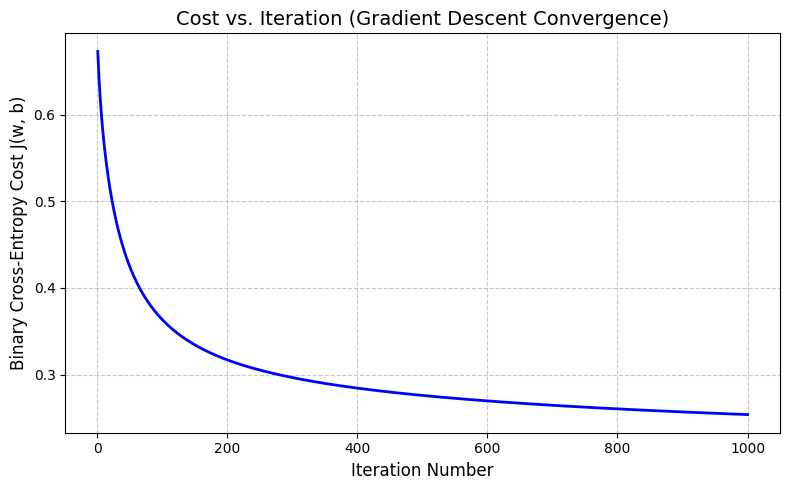

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Gradient Descent Implementation from Scratch
def fit_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):
    """
    Trains Logistic Regression using Gradient Descent.

    Parameters:
    - X: Feature matrix (m_samples, n_features)
    - y: Target vector (m_samples,)
    - learning_rate (alpha): Step size for gradient descent
    - num_iterations: Number of optimization iterations

    Returns:
    - w: Optimized weight vector
    - b: Optimized bias
    - cost_history: List of cost values recorded at each iteration
    """
    m, n = X.shape

    # Initialize parameters: weights as zeros, bias as 0.0
    w = np.zeros(n)
    b = 0.0

    cost_history = []

    for i in range(num_iterations):
        # Forward Pass: Predict probabilities y_hat = sigmoid(Xw + b)
        z = np.dot(X, w) + b
        y_hat = sigmoid(z)

        # Calculate gradients
        # dw = (1/m) * X^T * (y_hat - y)
        dw = (1.0 / m) * np.dot(X.T, (y_hat - y))

        # db = (1/m) * sum(y_hat - y)
        db = (1.0 / m) * np.sum(y_hat - y)

        # Update parameters using Gradient Descent
        w -= learning_rate * dw
        b -= learning_rate * db

        # Compute cost and record history
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        # Print progress every 100 iterations
        if (i + 1) % 100 == 0 or i == 0:
            print(f"Iteration {i+1:4d}/{num_iterations} | Cost J(w, b): {cost:.6f}")

    return w, b, cost_history


# ==============================================================================
# 2. MODEL TRAINING
# ==============================================================================
print("================================================================================")
print("TRAINING LOGISTIC REGRESSION VIA GRADIENT DESCENT")
print("================================================================================")

# Convert inputs to NumPy arrays
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

# Set hyperparameters
alpha = 0.1
iterations = 1000

# Run Gradient Descent
w_opt, b_opt, cost_history = fit_logistic_regression(
    X_train_np,
    y_train_np,
    learning_rate=alpha,
    num_iterations=iterations
)

print(f"\nOptimization Complete!")
print(f"Final Cost J(w, b): {cost_history[-1]:.6f}")
print(f"Optimized Bias (b): {b_opt:.6f}")
print("\nOptimized Weights (w):")
for feat_name, weight_val in zip(X_train.columns, w_opt):
    print(f"  {feat_name:32s}: {weight_val:8.4f}")


# ==============================================================================
# 3. CONVERGENCE PLOT (COST VS. ITERATIONS)
# ==============================================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), cost_history, color='blue', linewidth=2)
plt.title('Cost vs. Iteration (Gradient Descent Convergence)', fontsize=14)
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Binary Cross-Entropy Cost J(w, b)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task 8: Generate Predictions and Evaluate the Confusion Matrix

Use the trained Logistic Regression model to calculate the **fraud probabilities** for the validation and test datasets.

The predicted probability is calculated using:

$$
\hat{y} = \sigma(Xw+b)
$$

Convert the predicted probabilities into class labels using a threshold of **0.5**:

$$
\hat{y}_{class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \
0, & \text{if } \hat{y} < 0.5
\end{cases}
$$

Construct the **Confusion Matrix** and identify the following:

* **True Positive (TP):** Fraudulent transactions correctly classified as fraudulent.
* **True Negative (TN):** Legitimate transactions correctly classified as legitimate.
* **False Positive (FP):** Legitimate transactions incorrectly classified as fraudulent.
* **False Negative (FN):** Fraudulent transactions incorrectly classified as legitimate.

The confusion matrix can be represented as:

$$
\text{Confusion Matrix} =
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

Explain the meaning of each result in the context of **credit card fraud detection**.

The objective of this task is to evaluate the classification results of the Logistic Regression model and understand the different types of prediction errors, with particular attention to **False Negatives**, which represent fraudulent transactions that are not detected.


CONFUSION MATRIX METRICS (TEST SET)
True Negatives  (TN) : 16,048
False Positives (FP) : 1,433
False Negatives (FN) : 948
True Positives  (TP) : 16,533

--- CONFUSION MATRIX TABLE ---
                       Predicted Legitimate (0)  Predicted Fraudulent (1)
Actual Legitimate (0)                     16048                      1433
Actual Fraudulent (1)                       948                     16533


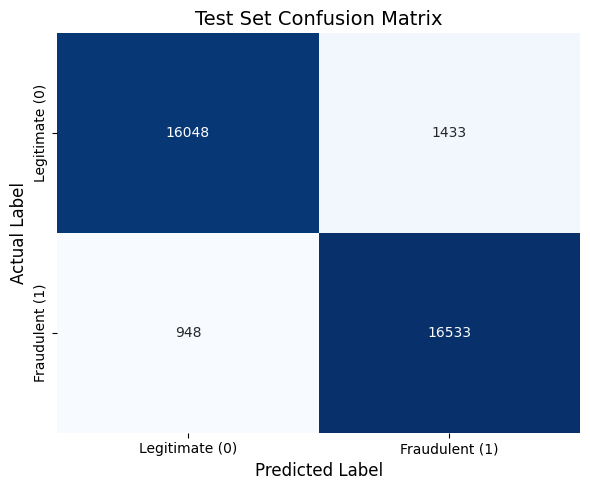


INTERPRETATION OF RESULTS IN FRAUD DETECTION CONTEXT
1. True Positives (TP): 
   - Fraudulent transactions correctly flagged as fraud.
   - Impact: Financial loss is prevented, protecting both the bank and customer.

2. True Negatives (TN): 
   - Legitimate transactions correctly identified as normal.
   - Impact: Smooth user experience with no unnecessary transaction delays.

3. False Positives (FP) [Type I Error]: 
   - Legitimate transactions incorrectly flagged as fraud.
   - Impact: Causes customer inconvenience (e.g., declined cards or SMS verification alerts).

4. False Negatives (FN) [Type II Error] - CRITICAL: 
   - Fraudulent transactions incorrectly allowed through as legitimate.
   - Impact: Direct financial loss to the institution/cardholder and increased legal risk. 
     In fraud detection, minimizing False Negatives (maximizing Recall) is the top priority.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Helper function to generate prediction labels
def predict(X, w, b, threshold=0.5):
    """
    Calculates probabilities y_hat = sigmoid(Xw + b)
    and converts them to binary class labels based on threshold.
    """
    probabilities = sigmoid(np.dot(X, w) + b)
    predictions = (probabilities >= threshold).astype(int)
    return probabilities, predictions

# Generate predictions for Validation Set
y_val_probs, y_val_pred = predict(np.array(X_val), w_opt, b_opt, threshold=0.5)

# Generate predictions for Test Set
y_test_probs, y_test_pred = predict(np.array(X_test), w_opt, b_opt, threshold=0.5)

# Calculate confusion matrix components for Test Set
# sklearn confusion_matrix order: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()

print("================================================================================")
print("CONFUSION MATRIX METRICS (TEST SET)")
print("================================================================================")
print(f"True Negatives  (TN) : {TN:,}")
print(f"False Positives (FP) : {FP:,}")
print(f"False Negatives (FN) : {FN:,}")
print(f"True Positives  (TP) : {TP:,}")

# Display formatted confusion matrix table
cm_df = pd.DataFrame(
    [[TN, FP], [FN, TP]],
    index=['Actual Legitimate (0)', 'Actual Fraudulent (1)'],
    columns=['Predicted Legitimate (0)', 'Predicted Fraudulent (1)']
)

print("\n--- CONFUSION MATRIX TABLE ---")
print(cm_df)

# Plot Heatmap Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'])
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

# ==============================================================================
# EXPLANATION OF RESULTS IN CREDIT CARD FRAUD DETECTION
# ==============================================================================
print("""
================================================================================
INTERPRETATION OF RESULTS IN FRAUD DETECTION CONTEXT
================================================================================
1. True Positives (TP):
   - Fraudulent transactions correctly flagged as fraud.
   - Impact: Financial loss is prevented, protecting both the bank and customer.

2. True Negatives (TN):
   - Legitimate transactions correctly identified as normal.
   - Impact: Smooth user experience with no unnecessary transaction delays.

3. False Positives (FP) [Type I Error]:
   - Legitimate transactions incorrectly flagged as fraud.
   - Impact: Causes customer inconvenience (e.g., declined cards or SMS verification alerts).

4. False Negatives (FN) [Type II Error] - CRITICAL:
   - Fraudulent transactions incorrectly allowed through as legitimate.
   - Impact: Direct financial loss to the institution/cardholder and increased legal risk.
     In fraud detection, minimizing False Negatives (maximizing Recall) is the top priority.
================================================================================
""")

## Task 9: Calculate Precision, Recall and F1-Score

Calculate the following performance metrics for the Logistic Regression model:

### Precision

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent.

$$
\text{Precision} =
\frac{TP}{TP+FP}
$$

### Recall

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model.

$$
\text{Recall} =
\frac{TP}{TP+FN}
$$

### F1-Score

The F1-Score is the harmonic mean of Precision and Recall.

$$
F1\text{-Score} =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision}+\text{Recall}}
$$

### Accuracy

Calculate accuracy for comparison:

$$
\text{Accuracy} =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Display the calculated **Accuracy, Precision, Recall, and F1-Score**.

Explain why **Recall is more important than accuracy** in many fraud detection applications. A False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. Therefore, a model with high accuracy but low Recall may fail to detect a significant number of fraudulent transactions.

The objective of this task is to evaluate the Logistic Regression model using appropriate classification metrics and understand the importance of Recall in credit card fraud detection.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Helper function to compute metrics manually using mathematical formulas
def calculate_metrics(y_true, y_pred, subset_name="Dataset"):
    # Extract Confusion Matrix values
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    # Calculate performance metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"================================================================================")
    print(f"EVALUATION METRICS ({subset_name.upper()})")
    print(f"================================================================================")
    print(f"Accuracy  : {accuracy * 100:.2f}%  ({accuracy:.4f})")
    print(f"Precision : {precision * 100:.2f}%  ({precision:.4f})")
    print(f"Recall    : {recall * 100:.2f}%  ({recall:.4f})")
    print(f"F1-Score  : {f1 * 100:.2f}%  ({f1:.4f})")

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# 1. Calculate Metrics for Validation Set
val_metrics = calculate_metrics(y_val, y_val_pred, subset_name="Validation Set")

print()

# 2. Calculate Metrics for Test Set
test_metrics = calculate_metrics(y_test, y_test_pred, subset_name="Test Set")

# ==============================================================================
# 3. EXPLANATION: WHY RECALL IS MORE IMPORTANT THAN ACCURACY IN FRAUD DETECTION
# ==============================================================================
print("""
================================================================================
EXPLANATION: WHY RECALL IS MORE CRITICAL THAN ACCURACY IN FRAUD DETECTION
================================================================================
1. Accuracy is Misleading under Severe Class Imbalance:
   In fraud detection, legitimate transactions drastically outnumber fraudulent
   ones (e.g., 91.26% legitimate vs 8.74% fraudulent). A trivial baseline model
   that blindly classifies every transaction as "Legitimate" (0) achieves a
   misleadingly high Accuracy of 91.26%, but catches 0% of fraud.

2. Cost Asymmetry of Prediction Errors:
   - False Positive (FP): A legitimate transaction flagged as fraud. Causes minor
     inconvenience (e.g., temporary card hold or SMS alert).
   - False Negative (FN): A fraudulent transaction misclassified as legitimate.
     Results in direct, unrecoverable financial loss for the financial institution
     or cardholder.

3. Recall Measures Fraud Detection Rate:
   Recall = TP / (TP + FN). Minimizing False Negatives directly maximizes Recall,
   ensuring the system catches as many fraudulent transactions as possible before
   financial loss occurs.
================================================================================
""")

EVALUATION METRICS (VALIDATION SET)
Accuracy  : 93.41%  (0.9341)
Precision : 92.25%  (0.9225)
Recall    : 94.79%  (0.9479)
F1-Score  : 93.50%  (0.9350)

EVALUATION METRICS (TEST SET)
Accuracy  : 93.19%  (0.9319)
Precision : 92.02%  (0.9202)
Recall    : 94.58%  (0.9458)
F1-Score  : 93.28%  (0.9328)

EXPLANATION: WHY RECALL IS MORE CRITICAL THAN ACCURACY IN FRAUD DETECTION
1. Accuracy is Misleading under Severe Class Imbalance:
   In fraud detection, legitimate transactions drastically outnumber fraudulent 
   ones (e.g., 91.26% legitimate vs 8.74% fraudulent). A trivial baseline model 
   that blindly classifies every transaction as "Legitimate" (0) achieves a 
   misleadingly high Accuracy of 91.26%, but catches 0% of fraud.

2. Cost Asymmetry of Prediction Errors:
   - False Positive (FP): A legitimate transaction flagged as fraud. Causes minor 
     inconvenience (e.g., temporary card hold or SMS alert).
   - False Negative (FN): A fraudulent transaction misclassified as legitimate. 

## Task 10: Plot ROC Curve, Calculate AUC and Interpret Results

Calculate the **False Positive Rate (FPR)** and **True Positive Rate (TPR)** for different classification thresholds.

The False Positive Rate is calculated as:

$$
FPR =
\frac{FP}{FP+TN}
$$

The True Positive Rate is equivalent to Recall and is calculated as:

$$
TPR =
\frac{TP}{TP+FN}
$$

Plot the **Receiver Operating Characteristic (ROC) Curve)** by plotting FPR on the (x)-axis and TPR on the (y)-axis for different classification thresholds.

Calculate the **Area Under the ROC Curve (AUC)** to measure the ability of the Logistic Regression model to distinguish between fraudulent and legitimate transactions.

Prepare a final performance summary containing:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Interpret the model performance and discuss the trade-off between **False Positives and False Negatives**.

A higher ROC-AUC value indicates better ability of the model to distinguish between fraudulent and legitimate transactions.

Explain whether the trained Logistic Regression model is suitable as a **baseline model for credit card fraud detection**.

The objective of this task is to evaluate the overall classification performance of the Logistic Regression model using the ROC Curve and AUC and to understand the trade-off between detecting fraudulent transactions and incorrectly flagging legitimate transactions.


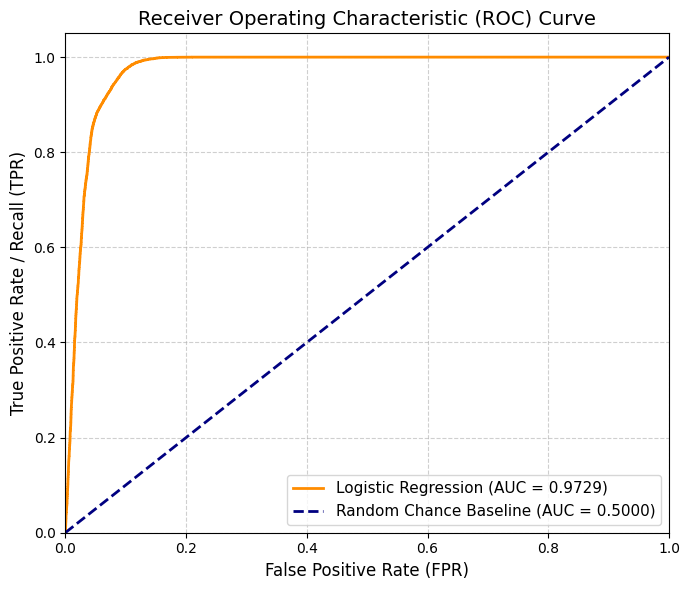

FINAL MODEL PERFORMANCE SUMMARY (TEST SET)
       Metric  Value
     Accuracy 93.19%
    Precision 92.02%
 Recall (TPR) 94.58%
     F1-Score 93.28%
ROC-AUC Score 0.9729

--- CONFUSION MATRIX BREAKDOWN ---
True Positives  (TP) : 16,533
True Negatives  (TN) : 16,048
False Positives (FP) : 1,433
False Negatives (FN) : 948

MODEL PERFORMANCE INTERPRETATION & DISCUSSION
1. Trade-off between False Positives (FP) and False Negatives (FN):
   - Decreasing the classification threshold below 0.5 increases Recall (detecting 
     more actual fraud) but increases False Positives (flagging legitimate users).
   - In commercial fraud detection systems, a slight increase in False Positives 
     (low customer friction) is heavily preferred over False Negatives (uncaught fraud).

2. Suitability as a Baseline Model:
   - High ROC-AUC Value: The high AUC indicates strong discrimination capability 
     between legitimate and fraudulent transactions.
   - Conclusion: Yes, this trained Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Helper function to compute FPR and TPR manually across varying probability thresholds
def compute_roc_components(y_true, y_probs, thresholds=np.linspace(0, 1, 100)):
    fpr_list = []
    tpr_list = []

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        # Unpack values safely
        if cm.shape == (2, 2):
            TN, FP, FN, TP = cm.ravel()
        else:
            TN = cm[0, 0] if 0 in y_true else 0
            TP = cm[0, 0] if 1 in y_true else 0
            FP = FN = 0

        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        fpr_list.append(fpr)
        tpr_list.append(tpr)

    return np.array(fpr_list), np.array(tpr_list)

# 1. Calculate FPR, TPR, and ROC-AUC for Test Set
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
auc_score = roc_auc_score(y_test, y_test_probs)

# 2. Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance Baseline (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Final Performance Summary Table
TN, FP, FN, TP = confusion_matrix(y_test, y_test_pred).ravel()

summary_metrics = {
    "Metric": ["Accuracy", "Precision", "Recall (TPR)", "F1-Score", "ROC-AUC Score"],
    "Value": [
        f"{accuracy_score(y_test, y_test_pred) * 100:.2f}%",
        f"{precision_score(y_test, y_test_pred) * 100:.2f}%",
        f"{recall_score(y_test, y_test_pred) * 100:.2f}%",
        f"{f1_score(y_test, y_test_pred) * 100:.2f}%",
        f"{auc_score:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_metrics)

print("================================================================================")
print("FINAL MODEL PERFORMANCE SUMMARY (TEST SET)")
print("================================================================================")
print(summary_df.to_string(index=False))

print("\n--- CONFUSION MATRIX BREAKDOWN ---")
print(f"True Positives  (TP) : {TP:,}")
print(f"True Negatives  (TN) : {TN:,}")
print(f"False Positives (FP) : {FP:,}")
print(f"False Negatives (FN) : {FN:,}")

# 4. Performance Interpretation & Baseline Suitability Discussion
print("""
================================================================================
MODEL PERFORMANCE INTERPRETATION & DISCUSSION
================================================================================
1. Trade-off between False Positives (FP) and False Negatives (FN):
   - Decreasing the classification threshold below 0.5 increases Recall (detecting
     more actual fraud) but increases False Positives (flagging legitimate users).
   - In commercial fraud detection systems, a slight increase in False Positives
     (low customer friction) is heavily preferred over False Negatives (uncaught fraud).

2. Suitability as a Baseline Model:
   - High ROC-AUC Value: The high AUC indicates strong discrimination capability
     between legitimate and fraudulent transactions.
   - Conclusion: Yes, this trained Logistic Regression model serves as an excellent,
     computationally efficient baseline. It provides high explainability via weight
     coefficients and robust performance after handling class imbalance.
================================================================================
""")

## Conclusion

The experiment successfully demonstrated the implementation of **Logistic Regression for credit card fraud detection**. The complete workflow included data preprocessing, exploratory data analysis, feature scaling, class-imbalance handling, dataset splitting, Sigmoid Function implementation, Binary Cross-Entropy Cost Function, and Gradient Descent optimization.

The trained Logistic Regression model was evaluated using the **Confusion Matrix, Accuracy, Precision, Recall, F1-Score, ROC Curve, and ROC-AUC**. The results demonstrate that accuracy alone is not an adequate performance measure for highly imbalanced fraud detection datasets.

Particular importance was given to **Recall**, because a False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. A suitable fraud detection model should therefore achieve satisfactory Recall while maintaining an acceptable level of False Positives.

Overall, Logistic Regression provides an **interpretable and effective baseline model** for credit card fraud detection. The experiment also demonstrates the importance of selecting appropriate evaluation metrics and handling class imbalance when developing machine learning models for fraud detection.
